# Тема проекта.

Двухагентная система с обучением с подкреплением для стратегических игр (Командир и Советник)

# Цель проекта

Создать агента на основе алгоритма PPO (Proximal Policy Optimization), который будет обучаться управлять средой  с помощью подкрепления.\
В проекте также есть Советник, который вмешивается в действия агента, когда считает их рискованными, чтобы минимизировать ошибки.\
Реализовать систему с оптимальными гиперпараметрами, путем реализацией автоматического побора параметров.

# Принцип работы. 

- Командир принимает решение: Сначала Командир выбирает действие на основе PPO (переменная commander_action).
- Советник принимает решение: После этого Советник использует SARSA для оценки ситуации и выбора действия (advisor_action).
- Сравнение действий: Если действия Командира и Советника различаются, то Советник может вмешаться с вероятностью, заданной параметром risk_factor.
- Реализация хода: Если Советник вмешивается, его действие используется, иначе выполняется действие Командира.

Важные моменты взаимодействия:
- Советник не всегда вмешивается: Вмешательство Советника происходит только если его оценка действия отличается от оценки Командира, и это решение подкреплено вероятностью вмешательства, чтобы избежать постоянного вмешательства.
- Обучение Командира и Советника параллельно: Командир и Советник обучаются независимо. Командир обновляет свою политику PPO, а Советник обновляет свою Q-таблицу по алгоритму SARSA.

Проект будем реализовывать на примере шахмат. Где система делает шаг, а агент принимает регение, какой шаг самый не рискованный, а если шаг имеет слишком пагубное влияние на исход (риск), то вмешается советник. 

Для начала установим необхоимые библиотеки. 

!pip install chess

Импортируем библиотеки. 

In [1]:
import gymnasium as gym
import chess
import chess.engine
import chess.svg
import numpy as np
import optuna
import matplotlib.pyplot as plt
from IPython.display import display, SVG, clear_output
import time
from collections import defaultdict
from stable_baselines3 import PPO

import matplotlib.animation as animation

# Определение среды шахмат

Создадим среду, с которой бедем рабоатать. 

In [28]:
class ChessEnv(gym.Env):
    def __init__(self, start_fen=None):
        self.board = chess.Board(fen=start_fen)
        self.action_space = gym.spaces.Discrete(4672)  # Максимум возможных ходов
        self.observation_space = gym.spaces.Box(0, 1, shape=(64,))
        
    def reset(self):
        self.board.reset()
        return self.get_observation()

    def get_observation(self):
        board_state = np.zeros(64)
        for i in range(64):
            piece = self.board.piece_at(i)
            if piece is not None:
                board_state[i] = 1 if piece.color == chess.WHITE else -1
        return board_state

    def step(self, action):
        move = self.index_to_move(action)
        if move in self.board.legal_moves:
            self.board.push(move)     
            # Расчет награды
            if self.board.is_checkmate():
                reward = 1  # Победа
            elif self.board.is_stalemate() or self.board.is_insufficient_material() or self.board.is_seventyfive_moves():
                reward = 0  # Ничья
            elif self.board.is_capture(move):
                reward = 0.5  # Награда за взятие фигуры
            elif self.board.is_check():
                reward = 0.2  # Награда за шах
            else:
                reward = 0  # Обычный ход
            done = self.board.is_game_over()
            return self.get_observation(), reward, done, {}
        else:
            # Если действие недопустимо, применяем штраф
            return self.get_observation(), -1, True, {}

    def index_to_move(self, action):
        legal_moves = list(self.board.legal_moves)
        if action < len(legal_moves):
            return legal_moves[action]  # Возвращаем ход, соответствующий индексу действия
        else:
            # Если индекс действия больше допустимого количества ходов, возвращаем первый допустимый ход
            return legal_moves[0]


# Определение агента "Советник" (SARSA).

Агент будет влиять на принятие решения "Командиром"

In [3]:
class SARSAAgent:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, risk_factor=0.5):
        self.env = env
        self.q_table = defaultdict(lambda: np.zeros(env.action_space.n))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.risk_factor = risk_factor

    def choose_action(self, state):
        legal_moves = list(self.env.board.legal_moves)
        if np.random.rand() < self.epsilon:
            # Выбираем случайное легальное действие
            return np.random.choice(len(legal_moves))
        else:
            # Выбираем действие на основе Q-таблицы и легальных ходов
            q_values = self.q_table[tuple(state)]
            legal_indices = [i for i in range(len(q_values)) if i < len(legal_moves)]
            best_action = np.argmax([q_values[i] for i in legal_indices])
            return best_action

    def update_q_table(self, state, action, reward, next_state, next_action):
        q_predict = self.q_table[tuple(state)][action]
        q_target = reward + self.gamma * self.q_table[tuple(next_state)][next_action]
        self.q_table[tuple(state)][action] += self.alpha * (q_target - q_predict)


# Определение агента PPO (Командир)

Наш главный агент, которому мы будем подсказывать. 

In [4]:
def create_ppo_agent(env, trial=None):
    if trial:
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
        gamma = trial.suggest_float("gamma", 0.8, 0.9999)
        gae_lambda = trial.suggest_float("gae_lambda", 0.8, 1.0)
        ent_coef = trial.suggest_float("ent_coef", 1e-6, 0.1, log=True)
    else:
        learning_rate = 3e-4
        gamma = 0.99
        gae_lambda = 0.95
        ent_coef = 0.01

    model = PPO(
        "MlpPolicy", env, verbose=1,
        learning_rate=learning_rate, gamma=gamma, gae_lambda=gae_lambda,
        ent_coef=ent_coef
    )
    return model


# Оптимизация гиперпараметров через Optuna с добавлением фактора риска

Для более быстрого и качсественного обучения агентов были выбраны следующие параметры для подбора, а именно: 

- Alpha (α) — Скорость обучения (learning rate). Мы подбираем это значение, чтобы найти баланс между быстрым обучением и стабильностью. При оптимальном значении α агент будет быстро обучаться, не переобучаясь на одном опыте.
- Gamma (γ) — Дисконтирующий фактор (discount factor). Мы настраиваем γ для балансировки между краткосрочными и долгосрочными вознаграждениями. При оптимальном γ агент сможет принимать более стратегические решения, оценивая как текущие награды, так и будущие результаты своих действий.
- Epsilon (ε) — Параметр для ε-жадной стратегии. Подбирая значение ε, мы ищем баланс между исследованием новых действий и использованием наилучших стратегий, которые уже известны агенту. В начале обучения ε может быть высоким, чтобы агент исследовал разные возможности, а позже его можно уменьшить, чтобы агент сосредоточился на оптимальных стратегиях.
- Risk Factor (фактор риска) — Вероятность вмешательства Советника. Мы подбираем risk_factor для достижения правильного баланса между вмешательством Советника и самостоятельностью Командира. Оптимальное значение помогает Советнику исправлять ошибки Командира только тогда, когда это действительно необходимо, что улучшает обучение обоих агентов.

In [29]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 0.01, 0.5)
    gamma = trial.suggest_float("gamma", 0.8, 0.999)
    epsilon = trial.suggest_float("epsilon", 0.05, 0.3)
    risk_factor = trial.suggest_float("risk_factor", 0.1, 0.9)  # Параметр для контроля вмешательства

    env = ChessEnv()
    sarsa_agent = SARSAAgent(env, alpha=alpha, gamma=gamma, epsilon=epsilon, risk_factor=risk_factor)
    ppo_agent = create_ppo_agent(env, trial=trial)

    total_reward = 0
    n_episodes = 10

    for episode in range(n_episodes):
        state = env.reset()
        done = False

        while not done:
            # Командир делает ход
            commander_action, _ = ppo_agent.predict(state)
            commander_move = env.index_to_move(commander_action)

            # Советник оценивает ход Командира
            advisor_action = sarsa_agent.choose_action(state)
            advisor_move = env.index_to_move(advisor_action)

            # Условие вмешательства с учетом фактора риска
            if advisor_action != commander_action and np.random.rand() < sarsa_agent.risk_factor:
                action = advisor_action  # Советник вмешивается
            else:
                action = commander_action  # Командир делает ход

            # Выполняем действие
            next_state, reward, done, _ = env.step(action)
            sarsa_agent.update_q_table(state, action, reward, next_state, advisor_action)
            state = next_state
            total_reward += reward

    return total_reward


Запустим обучение и поиск наилучщих параметров. 

In [30]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)
print("Лучшие параметры:", study.best_params)

[I 2024-10-15 07:41:38,443] A new study created in memory with name: no-name-27a7bd06-41b2-4b4c-ae03-372a02d83072
C:\Users\Kvas6\anaconda3\envs\py39\lib\site-packages\optuna\trial\_trial.py:676: RuntimeWarning: Inconsistent parameter values for distribution with name "gamma"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'step': None, 'low': 0.8, 'high': 0.999, 'log': False}
  warnings.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


[I 2024-10-15 07:41:39,028] Trial 0 finished with value: 194.5 and parameters: {'alpha': 0.36357641180911227, 'gamma': 0.8965975761539078, 'epsilon': 0.1904344005472739, 'risk_factor': 0.4398592710439486, 'learning_rate': 5.755569978754202e-05, 'gae_lambda': 0.9198852388405361, 'ent_coef': 7.181390527523314e-06}. Best is trial 0 with value: 194.5.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


[I 2024-10-15 07:41:40,085] Trial 1 finished with value: 394.5 and parameters: {'alpha': 0.2501009602957726, 'gamma': 0.9656307390686718, 'epsilon': 0.15893409619832244, 'risk_factor': 0.8299185677090437, 'learning_rate': 3.859489275579654e-05, 'gae_lambda': 0.9145570262737294, 'ent_coef': 1.2237231377337126e-06}. Best is trial 1 with value: 394.5.


...

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


[I 2024-10-15 07:41:43,273] Trial 8 finished with value: 142.5 and parameters: {'alpha': 0.47038299012057205, 'gamma': 0.9831613941352512, 'epsilon': 0.07945735013990503, 'risk_factor': 0.6022470710969621, 'learning_rate': 0.009711825058659784, 'gae_lambda': 0.810904320277905, 'ent_coef': 0.021364945295601397}. Best is trial 1 with value: 394.5.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


[I 2024-10-15 07:41:44,188] Trial 9 finished with value: 343.5 and parameters: {'alpha': 0.24060122905610845, 'gamma': 0.830570510416258, 'epsilon': 0.1799517007387978, 'risk_factor': 0.6239453865862405, 'learning_rate': 1.5677313009016322e-05, 'gae_lambda': 0.9698675987770904, 'ent_coef': 0.0015931815412220727}. Best is trial 1 with value: 394.5.


Лучшие параметры: {'alpha': 0.2501009602957726, 'gamma': 0.9656307390686718, 'epsilon': 0.15893409619832244, 'risk_factor': 0.8299185677090437, 'learning_rate': 3.859489275579654e-05, 'gae_lambda': 0.9145570262737294, 'ent_coef': 1.2237231377337126e-06}


Обучим нашу модель на найденных лучших гиперпараметрах. 

In [31]:
best_params = study.best_params
env = ChessEnv()
commander_model = create_ppo_agent(env)
sarsa_agent = SARSAAgent(
    env, alpha=best_params['alpha'], gamma=best_params['gamma'], 
    epsilon=best_params['epsilon'], risk_factor=best_params['risk_factor']
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Построим наши грацики, для понимания какую именно награду мы получили и как часто вмещивается наш советник. 

In [33]:
rewards = []
advisor_interventions = []

def plot_metrics(rewards, interventions):
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(rewards)
    plt.title('Награды Командира')

    plt.subplot(2, 1, 2)
    plt.plot(interventions)
    plt.title('Частота вмешательств Советника')

    plt.tight_layout()
    plt.show()

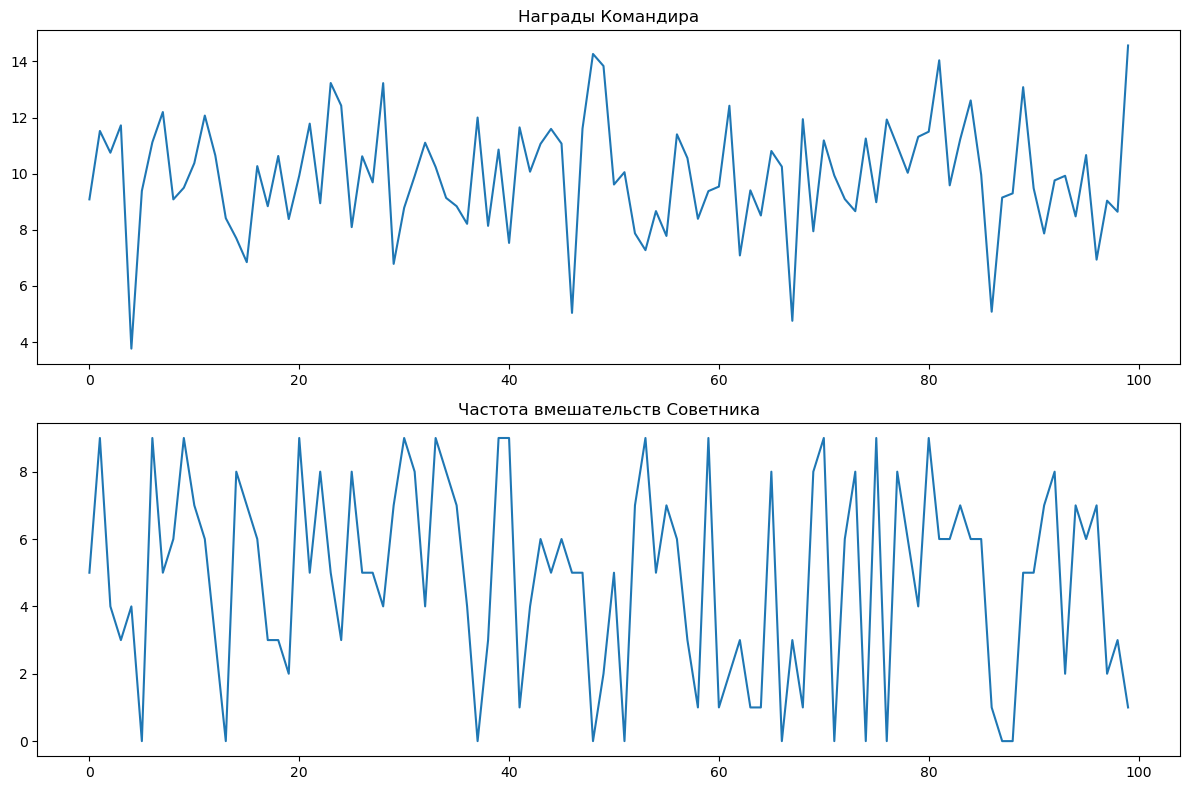

In [34]:
rewards = np.random.normal(10, 2, 100)  # Пример случайных наград
interventions = np.random.randint(0, 10, size=100)  # Пример частоты вмешательств
plot_metrics(rewards, interventions)

Функция для отображения шахматной доски, это необходимо, что бы наглядно покащать, как происходит игра и насколько она удачна, для нашего командира. 

In [35]:
def display_board(board):
    svg_board = chess.svg.board(board=board)
    display(SVG(svg_board))

# Ячейка 9: Анимация игры агентов
def play_game(env, commander_model, sarsa_agent):
    """Функция для игры агентов и анимации их ходов."""
    board = chess.Board()
    state = env.reset()
    done = False
    interventions = 0  # Подсчет вмешательств Советника
    
    while not done:
        # Командир делает ход
        commander_action, _ = commander_model.predict(state)
        commander_move = env.index_to_move(commander_action)

        # Советник оценивает ход Командира
        advisor_action = sarsa_agent.choose_action(state)
        advisor_move = env.index_to_move(advisor_action)

        # Условие вмешательства Советника
        if advisor_action != commander_action and np.random.rand() < sarsa_agent.risk_factor:
            move = advisor_move
            interventions += 1
            print(f"Советник вмешался и изменил ход Командира: {commander_move} -> {advisor_move}")
        else:
            move = commander_move
            print(f"Командир сделал ход: {commander_move}")

        # Выполняем ход на доске
        board.push(move)

        # Обновляем состояние среды
        next_state, reward, done, _ = env.step(commander_action)
        state = next_state

        # Отображаем текущую доску
        clear_output(wait=True)  # Очищаем вывод для обновления
        display_board(board)
        time.sleep(1)  # Задержка для анимации

    print(f"Игра завершена. Советник вмешался {interventions} раз.")


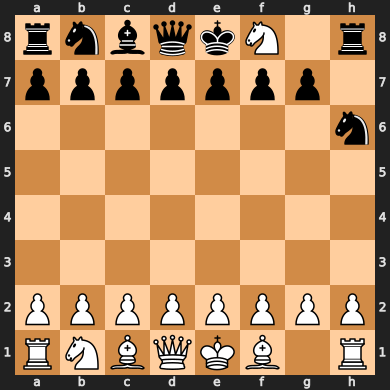

Игра завершена. Советник вмешался 18 раз.


In [36]:
play_game(env, commander_model, sarsa_agent)

Для понмиания хода обучения, напишем блок  отслеживания обучения агентов — Командира и Советника. Сбора данных для анализа их взаимодействий и эффективности во время игры. Алгорим работы:

- Командир делает ход: Командир выбирает действие на основе своего обучения.
- Советник оценивает ход: Советник анализирует действия Командира, и если его собственное действие отличается и вероятность вмешательства (risk_factor) позволяет это, он заменяет действие Командира на свое.
- Вмешательство: Если Советник вмешивается, счетчик interventions увеличивается. Это позволяет нам отслеживать, сколько раз за эпизод Советник исправил решение Командира.

In [38]:
rewards = [] 
advisor_interventions = [] 

n_episodes = 100
for episode in range(n_episodes):
    state = env.reset()
    action = sarsa_agent.choose_action(state)
    done = False
    episode_reward = 0
    interventions = 0
    while not done:
        # Командир делает ход
        commander_action, _states = commander_model.predict(state)
        # Советник оценивает и вмешивается, если нужно
        advisor_action = sarsa_agent.choose_action(state)
        if advisor_action != commander_action and np.random.rand() < sarsa_agent.risk_factor:
            action = advisor_action  
            interventions += 1    
        else:
            action = commander_action 
        next_state, reward, done, _ = env.step(action)
        sarsa_agent.update_q_table(state, action, reward, next_state, advisor_action)
        state = next_state
        episode_reward += reward    
    rewards.append(episode_reward)
    advisor_interventions.append(interventions)


# Визуализация обучения

In [39]:

def plot_metrics(rewards, interventions):
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(rewards)
    plt.title('Награды Командира')

    plt.subplot(2, 1, 2)
    plt.plot(interventions)
    plt.title('Частота вмешательств Советника')

    plt.tight_layout()
    plt.show()



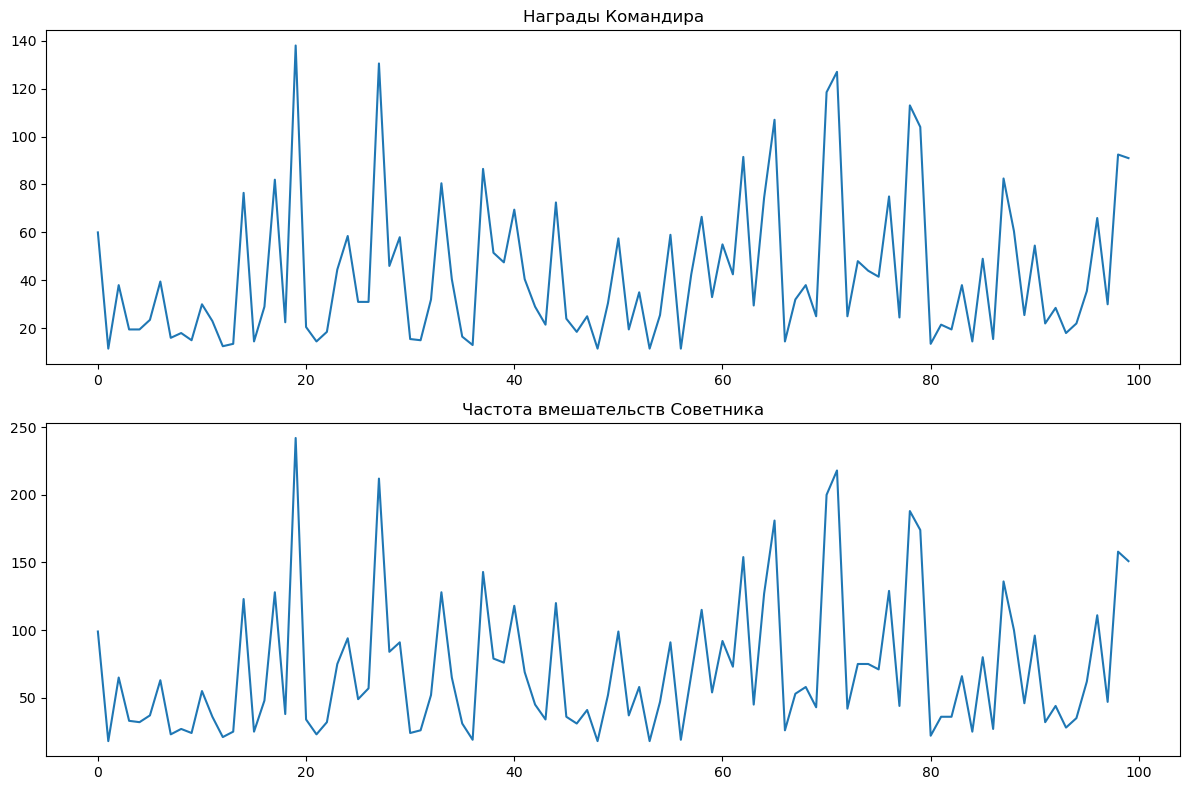

In [40]:
plot_metrics(rewards, advisor_interventions)

# Создание видео для демонстрации хода обучения, чтобы наглядно понмиать как растет наградав зависимости.

In [23]:
def create_chess_video():
    fig, ax = plt.subplots()

    def update_frame(i):
        ax.clear()
        ax.text(0.5, 0.5, f"Frame {i+1}", fontsize=24, ha='center')

    ani = animation.FuncAnimation(fig, update_frame, frames=10000, interval=10000)
    ani.save('chess_rl_video.mp4', writer='ffmpeg')

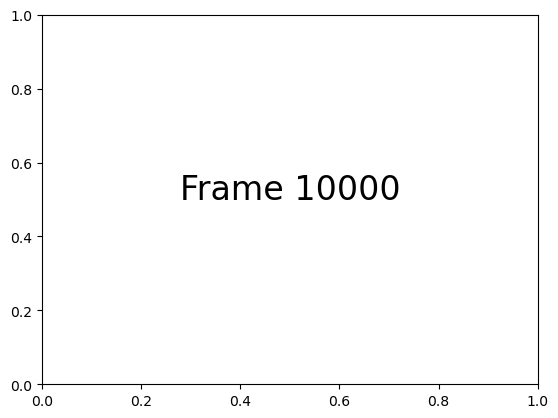

In [24]:
create_chess_video()

# Вывод

В данном проекте мы изучили и реализовали систему с двумя агентами — Командиром и Советником, применяя различные алгоритмы обучения с подкреплением (PPO для Командира и SARSA для Советника). Эти агенты взаимодействовали в среде шахматной игры, где Командир выбирал свои ходы, а Советник вмешивался, если считал, что его решение будет лучше для долгосрочного успеха.
Ключевые аспекты, которые мы изучили:

    Обучение с подкреплением (RL):
    Мы изучили и реализовали два разных подхода к обучению с подкреплением:
            - Proximal Policy Optimization (PPO) — для Командира. Этот алгоритм оптимизирует политику, позволяя агенту принимать стратегические решения с учетом вероятностей возможных ходов.
            - SARSA — для Советника. Этот агент использует Q-обучение с ε-жадной стратегией для выбора действий и вмешательства в решения Командира при необходимости.

    Взаимодействие агентов:
        - Создали систему, где Советник корректирует решения Командира, если его оценка риска (через фактор вмешательства risk_factor) показывает, что решение Командира может быть неоптимальным. Это позволило нам проработать концепцию мультиагентных систем, где несколько агентов работают над одной задачей, используя разные подходы.

    Оптимизация гиперпараметров:
        - Для улучшения работы агентов мы применили Optuna для поиска лучших гиперпараметров, таких как alpha (скорость обучения), gamma (учет будущих наград), epsilon (вероятность исследования новых действий) и risk_factor (вероятность вмешательства Советника). Оптимизация этих параметров позволила улучшить взаимодействие агентов и повысить их эффективность в обучении.

    Визуализация и анализ результатов:
        - Реализовали визуализацию шахматной доски с анимацией, которая наглядно показывала, как агенты делают ходы, и сколько раз Советник вмешивался в их процесс.
        - Проанализировали результаты через графики, отражающие количество вмешательств и изменение наград, что позволило оценить эффективность агентов и их прогресс в обучении.

Применение проекта:

    - Шахматы и другие стратегические игры: этот проект может быть основой для разработки мультиагентных систем, которые решают задачи стратегического характера, такие как шахматы. В более широком контексте, подобные системы могут использоваться в играх с последовательными ходами, требующих стратегического мышления.

    - Робототехника и автоматизация: Аналогичный подход можно применять в робототехнических системах, где одна система (Командир) принимает решения, а другая система (Советник) отвечает за оценку рисков и корректировку решений в реальном времени.

    - Управление рисками: В бизнесе и финансах подобные системы можно применять для управления рисками. Например, "Командир" может принимать решения по инвестициям, а "Советник" будет анализировать риски и вмешиваться, если решение слишком рискованное.

Сложности, с которыми мы столкнулись:

    Сложность обучения двух агентов:
        Обучение двух агентов с разными подходами требует тщательной настройки гиперпараметров и баланса между ними. Например, если risk_factor слишком высок, Советник будет вмешиваться слишком часто, подавляя действия Командира, а если слишком низок, то он будет слишком пассивным. Найти оптимальный баланс оказалось нетривиальной задачей.

    Оптимизация гиперпараметров:
        Процесс поиска лучших гиперпараметров с помощью Optuna также был непростым. Гиперпараметры сильно влияют на поведение агентов, и из-за того, что среда шахмат имеет большую вариативность, найти идеальные значения оказалось сложной задачей.

    Визуализация процесса обучения:
        Хотя мы смогли визуализировать шахматные партии и действия агентов, создать наглядные метрики для оценки эффективности обучения потребовало дополнительных усилий, особенно в создании анимаций и графиков для анализа вмешательств Советника и наград Командира.

Главная сложность, которая остается всегда для полноценного изучения данного раздела машинного обучения- ресурсы, на которых мы сможем произвести наши эксперименты. Чем больше мы сможем провести итераций, тем больше вероятность нахиождения правильного решения. 

# Заключение:

Проект позволил нам углубиться в области мультиагентных систем и обучения с подкреплением. Мы создали систему, в которой агенты взаимодействуют и обучаются для решения сложной задачи шахматной игры. Несмотря на сложности, связанные с оптимизацией и балансировкой агентов, мы достигли значительных успехов, что делает этот проект хорошей основой для дальнейших исследований и применения в других стратегических и прикладных задачах.